In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder


I0000 00:00:1773431577.879119    1205 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773431578.765668    1205 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773431581.646775    1205 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
df = pd.read_csv("../processed/combined.csv")
df= df[["statement", "status"]]
df = df.dropna()

df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"all wrong, back off dear, forward doubt. stay ...",Anxiety
3,i've shifted my focus to something else but i'...,Anxiety
4,"i'm restless and restless, it's been a month n...",Anxiety


In [3]:
df["status"].value_counts()


status
Normal        34734
Depression    29910
Suicidal      21863
Anxiety        9344
Name: count, dtype: int64

In [4]:
encoder = LabelEncoder()
y = encoder.fit_transform(df["status"]) 

In [5]:
vectorizer = CountVectorizer(max_features=5000)
X = vectorizer.fit_transform(df["statement"]).toarray()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(len(np.unique(y)), activation='softmax')
])  

/home/shadrs/anaconda3/envs/info629project/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1773431593.610096    1205 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1773431593.610752    1484 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1773431593.644958    1205 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you 

In [8]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [9]:
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/5
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.7889 - loss: 0.5329 - val_accuracy: 0.8350 - val_loss: 0.4136
Epoch 2/5
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.8589 - loss: 0.3546 - val_accuracy: 0.8523 - val_loss: 0.3747
Epoch 3/5
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.8995 - loss: 0.2702 - val_accuracy: 0.8741 - val_loss: 0.3599
Epoch 4/5
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.9263 - loss: 0.1989 - val_accuracy: 0.8884 - val_loss: 0.3475
Epoch 5/5
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.9439 - loss: 0.1662 - val_accuracy: 0.8977 - val_loss: 0.3311


In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_probs = model.predict(X_test)
y_pred = np.argmax(y_probs, axis=1) 

print(f"Shapes y_test: {y_test.shape}, y_pred: {y_pred.shape}")



600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Shapes y_test: (19171,), y_pred: (19171,)


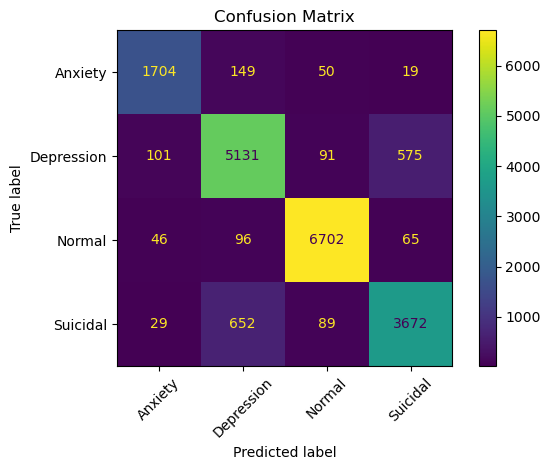

In [15]:
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display it with class labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
# disp.plot(cmap='Blues', xticks_rotation=45)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [16]:
model.save("neural_network.model.h5")
with open("vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)